<a href="https://colab.research.google.com/github/csabiu/Cosmology_Course/blob/main/practical/sdss_2pcf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/csabiu/Cosmology_Course/blob/main/practical/sdss_2pcf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Galaxy Clustering with SDSS
### From angular catalogues to BAO, RSD, and the Alcock$-$Paczy\'{n}ski test

---

In this practical you will measure and interpret the **two-point correlation function** $\xi(r)$ of a real galaxy survey, following the same logical chain we developed in the lecture:

1. **Build the data + random catalogues** and convert sky coordinates to comoving 3D positions
2. **Small-scale $\xi(r)$:** measure the power-law regime and fit the correlation length $r_0$ and slope $\gamma$
3. **Large-scale $\xi(r)$:** detect the BAO bump and fit the dilation parameter $\alpha$ to recover $D_V/r_d$
4. **Anisotropic $\xi(\sigma,\pi)$:** see the Kaiser squashing and Fingers of God; extract the growth rate combination $f\sigma_8$
5. **Alcock$-$Paczy\'{n}ski distortion:** how an incorrect fiducial cosmology warps the 2D clustering pattern

**Prerequisites:** Lecture 9 (galaxy clustering, BAO, RSD).

**Exercises:** 1 main exercise (Fingers of God) + several short "try it" prompts. Estimated time: 2 hours.

## Part 0 --- Setup

In [1]:
!pip install -q camb
!git clone -q https://github.com/csabiu/kstat.git
!cd kstat/src && make -s

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 21.9 MB/s eta 0:00:00
kdtree2.F90:1494:38:

 1494 |   logical function box_in_search_range(node, sr) result(res)
      |                                      ^
kdtree2.F90:1817:21:

 1817 |   subroutine heapsort(a,ind,n)
      |                     ^
kdtree2.F90:345:27:

  345 |   subroutine pq_adjust_heap(a,i)
      |                           ^
jackknife.F90:42:66:

   42 |   integer :: i, j, k, n, group_size, remainder, start_idx, end_idx
      |                                                                  1
jackknife.F90:42:35:

   42 |   integer :: i, j, k, n, group_size, remainder, start_idx, end_idx
      |                                   1
jackknife.F90:42:20:

   42 |   integer :: i, j, k, n, group_size, remainder, start_idx, end_idx
      |                    1
jackknife.F90:42:46:

   42 |   integer :: i, j, k, n, group_size, remainder, start_idx, end_idx
      |                                              1
jackk

In [2]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.cosmology import FlatLambdaCDM, FlatwCDM
from astropy.coordinates import SkyCoord
from astropy import units as u
from scipy.optimize import minimize, curve_fit
from scipy import integrate
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Course plot defaults
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'legend.fontsize': 11,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# ============================================================
# Planck 2018 fiducial cosmology
# ============================================================
H0      = 67.36   # km/s/Mpc
Om0     = 0.3153  # total matter density
Ob0     = 0.0493  # baryon density
ns      = 0.9649  # primordial spectral index
As      = 2.1e-9  # primordial amplitude
sigma8  = 0.811   # sigma_8
h       = H0 / 100.0
ckms    = 299792.458  # km/s

# Working units throughout: Mpc/h with H0 = 100
cosmo_h = FlatLambdaCDM(Om0=Om0, H0=100.0)

print(f'Planck 2018 fiducial: H0={H0}, Om0={Om0}, Ob0={Ob0}, sigma8={sigma8}')

Planck 2018 fiducial: H0=67.36, Om0=0.3153, Ob0=0.0493, sigma8=0.811


## Part 1 --- Data and randoms

We use the **SDSS BOSS DR10 CMASS** sample (South Galactic Cap), one of the cleanest large-scale-structure samples ever assembled.  CMASS is dominated by Luminous Red Galaxies (LRGs) at $0.4 < z < 0.7$, with linear bias $b\sim 2$.

Each redshift survey delivers two catalogues:

- A **data** catalogue with galaxy (RA, Dec, $z$) plus systematics weights
- One or more **random** catalogues that share the survey angular mask + radial selection function but are otherwise *unclustered*

Both are needed for the Landy$-$Szalay estimator
$$\hat\xi(r) = \frac{DD(r) - 2\,DR(r) + RR(r)}{RR(r)}.$$
Without randoms we cannot disentangle real clustering from the survey window.

In [9]:
!wget https://data.sdss.org/sas/dr10/boss/lss/galaxy_DR10v8_CMASS_South.fits.gz
!wget https://data.sdss.org/sas/dr10/boss/lss/random1_DR10v8_CMASS_South.fits.gz
!ls -lh galaxy_DR10v8_CMASS_South.fits.gz random1_DR10v8_CMASS_South.fits.gz

--2026-04-29 01:51:07--  https://data.sdss.org/sas/dr10/boss/lss/random1_DR10v8_CMASS_South.fits.gz
Resolving data.sdss.org (data.sdss.org)... 155.101.19.133
Connecting to data.sdss.org (data.sdss.org)|155.101.19.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 194409599 (185M) [application/octet-stream]
Saving to: ‘random1_DR10v8_CMASS_South.fits.gz.2’

random1_DR10v8_CMAS 100%[===================>] 185.40M   114KB/s    in 21m 24s 

2026-04-29 02:12:32 (148 KB/s) - ‘random1_DR10v8_CMASS_South.fits.gz.2’ saved [194409599/194409599]

-rw-r--r-- 1 root root 22M Aug 27  2013 galaxy_DR10v8_CMASS_South.fits.gz
-rw-r--r-- 1 root root 30M Apr 29 01:10 random1_DR10v8_CMASS_South.fits.gz


### 1.1 --- Read the galaxy catalogue

BOSS galaxies carry several systematics weights.  Following [Reid et al.\ 2016](https://arxiv.org/abs/1607.03155), the total per-galaxy weight is:
$$w_{\rm tot} = w_{\rm sys}\,w_{\rm FKP}\,(w_{\rm CP} + w_{\rm NOZ} - 1)$$
with `WEIGHT_SYSTOT` correcting for imaging systematics, `WEIGHT_FKP` an FKP weight (optimal for $P(k)$), and the close-pair / redshift-failure weights handling fibre-collision effects.

In [16]:
hdul = fits.open('galaxy_DR10v8_CMASS_South.fits.gz')
ra    = hdul[1].data['RA']
dec   = hdul[1].data['DEC']
zg    = hdul[1].data['Z']
wsys  = hdul[1].data['WEIGHT_SYSTOT']
wcp   = hdul[1].data['WEIGHT_CP']
wnoz  = hdul[1].data['WEIGHT_NOZ']
wfkp  = hdul[1].data['WEIGHT_FKP']
wgal  = wsys * wfkp * (wcp + wnoz - 1.0)

print(f'{len(ra)} galaxies in the input catalogue')
print(f'Effective sum of weights: {wgal.sum():.0f}')

120971 galaxies in the input catalogue
Effective sum of weights: 28756


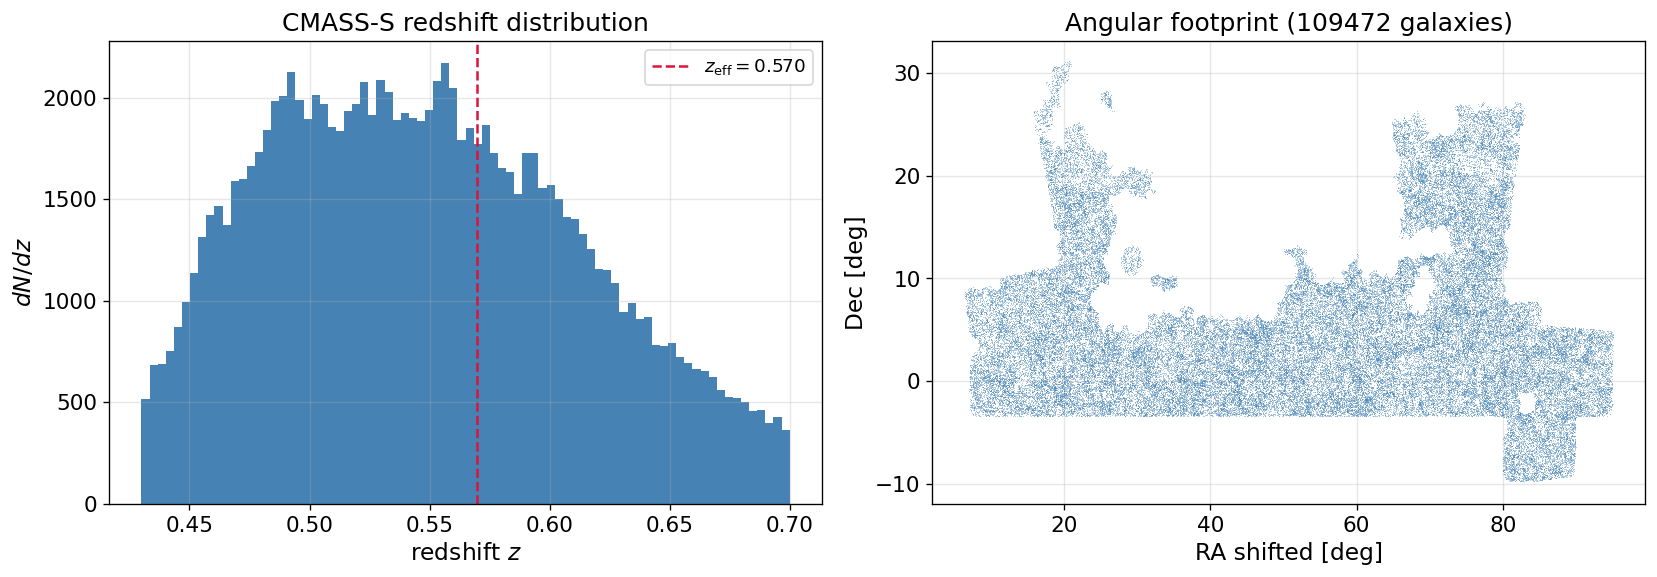

In [17]:
zmin, zmax = 0.43, 0.70   # CMASS redshift cuts
ind = (zg > zmin) & (zg < zmax)
z_eff = np.average(zg[ind], weights=wgal[ind])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(zg[ind], bins=80, color='steelblue')
ax[0].axvline(z_eff, color='crimson', ls='--', label=f'$z_{{\\rm eff}} = {z_eff:.3f}$')
ax[0].set_xlabel('redshift $z$'); ax[0].set_ylabel('$dN/dz$')
ax[0].set_title('CMASS-S redshift distribution')
ax[0].legend()

ax[1].plot(np.mod(ra[ind] + 50, 360), dec[ind], ',', color='steelblue', alpha=0.4)
ax[1].set_xlabel('RA shifted [deg]'); ax[1].set_ylabel('Dec [deg]')
ax[1].set_title(f'Angular footprint ({ind.sum()} galaxies)')
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 1.2 --- From sky coordinates to comoving Cartesian positions

We assume a fiducial flat-$\Lambda$CDM cosmology with $\Omega_m=0.30$ and $H_0=100\,h\,$km/s/Mpc, so all distances come out in $\mathrm{Mpc}/h$.
$$r(z) = \frac{c}{H_0}\int_0^z \frac{dz'}{\sqrt{\Omega_m(1+z')^3 + \Omega_\Lambda}}$$

In [12]:
dist = cosmo_h.comoving_distance(zg[ind]).value          # Mpc/h
c    = SkyCoord(ra=ra[ind]*u.deg, dec=dec[ind]*u.deg, distance=dist*u.Mpc)
data = np.column_stack((c.cartesian.x.value,
                         c.cartesian.y.value,
                         c.cartesian.z.value,
                         wgal[ind]))
np.savetxt('gal.txt', data)
print(f'Wrote gal.txt: {data.shape[0]} galaxies x {data.shape[1]} columns (x,y,z,w)')

Wrote gal.txt: 109472 galaxies x 4 columns (x,y,z,w)


### 1.3 --- Build the random catalogue

The random catalogue traces the survey window: same angular mask, same $dN/dz$, same fibre-collision corrections, but no clustering.  Below we read DR10 random file `random1_*`, apply the same redshift cuts, and convert to Cartesian coordinates.

In [18]:
hdul  = fits.open('random1_DR10v8_CMASS_South.fits.gz')
rar   = hdul[1].data['RA']
decr  = hdul[1].data['DEC']
zr    = hdul[1].data['Z']
wrand = hdul[1].data['WEIGHT_FKP']
indr  = (zr > zmin) & (zr < zmax)

print(f'{indr.sum()} randoms after the redshift cut')

5345587 randoms after the redshift cut


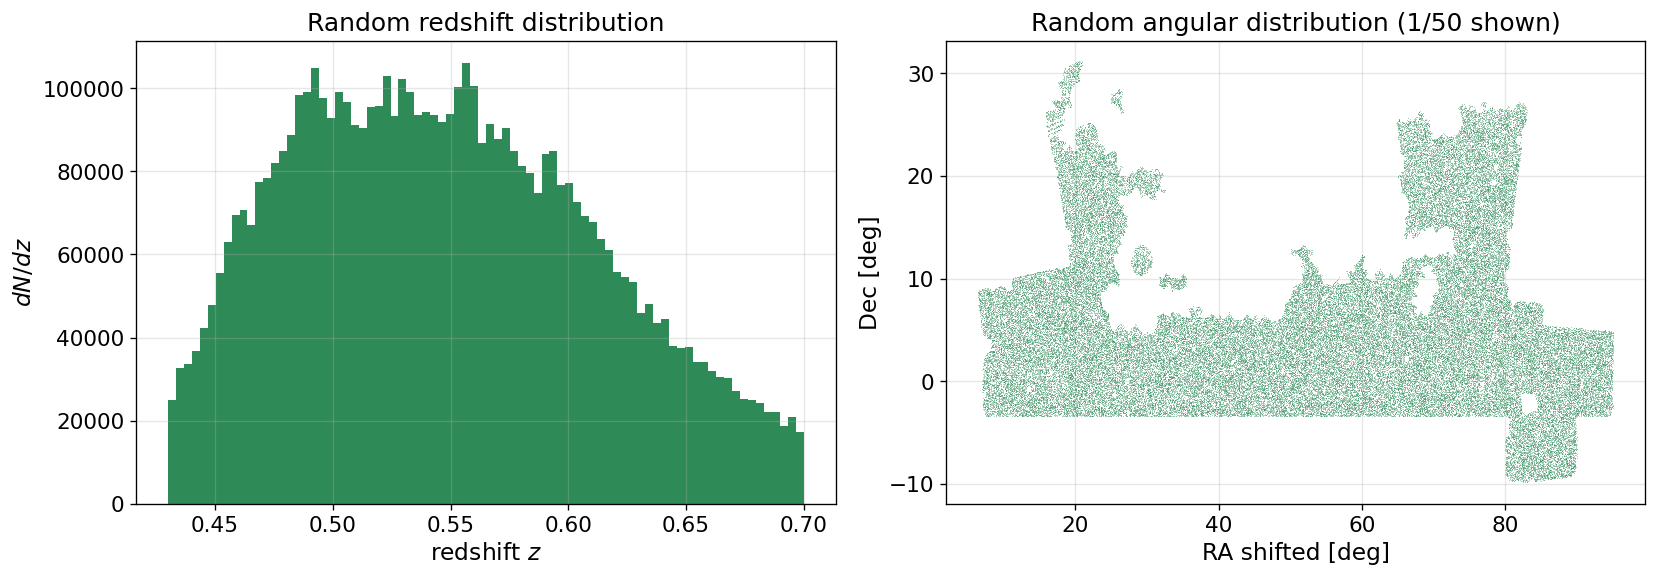

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(zr[indr], bins=80, color='seagreen')
ax[0].set_xlabel('redshift $z$'); ax[0].set_ylabel('$dN/dz$')
ax[0].set_title('Random redshift distribution')

ax[1].plot(np.mod(rar[indr][::50]+50, 360), decr[indr][::50], ',', color='seagreen', alpha=0.4)
ax[1].set_xlabel('RA shifted [deg]'); ax[1].set_ylabel('Dec [deg]')
ax[1].set_title('Random angular distribution (1/50 shown)')
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [20]:
distr = cosmo_h.comoving_distance(zr[indr]).value
cr    = SkyCoord(ra=rar[indr]*u.deg, dec=decr[indr]*u.deg, distance=distr*u.Mpc)
rand  = np.column_stack((cr.cartesian.x.value,
                          cr.cartesian.y.value,
                          cr.cartesian.z.value,
                          wrand[indr]))
# Subsample 1/50 to keep KSTAT fast in the practical (use ~20x N_data)
np.savetxt('ran.txt', rand[::50, :])
print(f'Wrote ran.txt: {rand[::50,:].shape[0]} randoms (1/50 subsample)')

Wrote ran.txt: 106912 randoms (1/50 subsample)


## Part 2 --- Small-scale $\xi(r)$: power-law fit

On scales $r \lesssim 20\,h^{-1}\mathrm{Mpc}$ the galaxy 2-point correlation function is well approximated by a single power law (Davis \& Peebles 1983):
$$\boxed{\;\xi(r) = \left(\frac{r}{r_0}\right)^{-\gamma}\;}$$
with $r_0$ the *correlation length* (the scale at which $\xi=1$) and $\gamma$ the slope.  For optical galaxy samples $r_0 \sim 5\,h^{-1}\mathrm{Mpc}$ and $\gamma\sim 1.8$.

Why a power law?  On these scales clustering is dominated by 1-halo + 2-halo transition, plus pair conservation arguments give a stable $\gamma\approx 1.8$ for a wide range of cosmologies.  Pinning $r_0$ down measures the galaxy-halo connection (more massive haloes $\to$ larger $r_0$).

In [21]:
# 20 logarithmic bins from 1 to 60 Mpc/h, isotropic, weighted (~1 min)
!kstat/bin/2pcf -gal gal.txt -ran ran.txt -rmin 1.0 -rmax 60.0 -nbins 20 -log .true. -wgt .true. > out.txt 2>&1
!head -1 result.txt

R_min, R_max, DD, DR, RR, XI_natural, XI_Davis, XI_LS (most accurate)


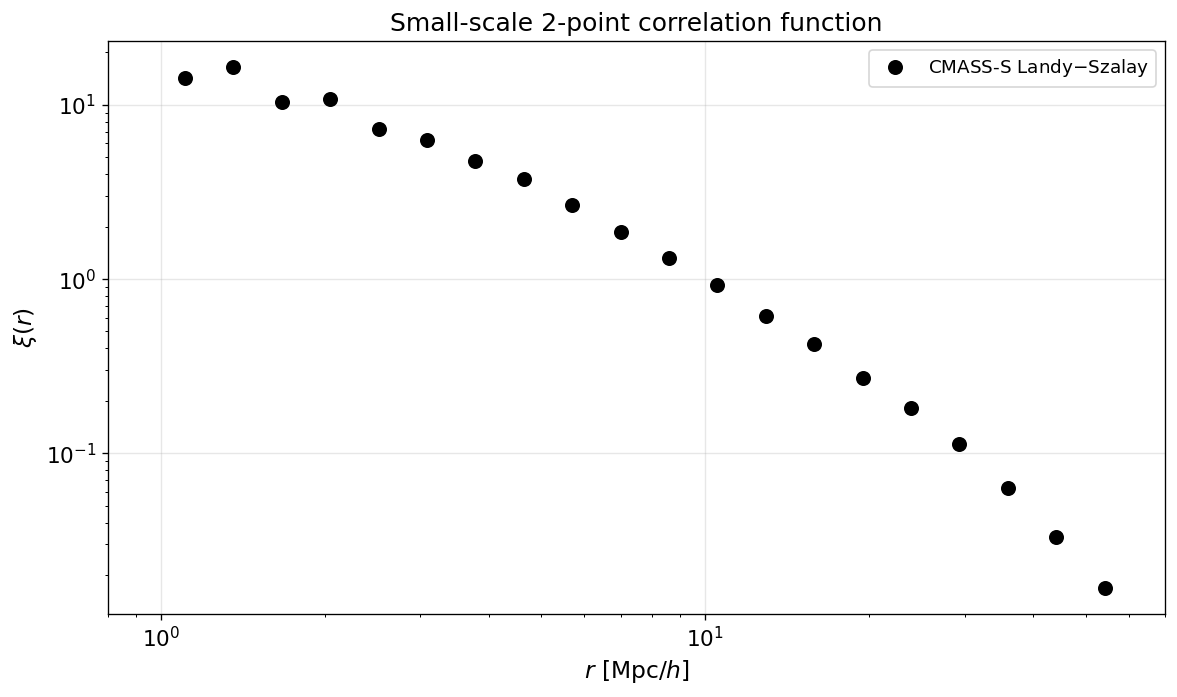

In [22]:
x = np.loadtxt('result.txt', skiprows=1)
r_small  = np.sqrt(x[:,0] * x[:,1])    # geometric mean of bin edges (good for log bins)
xi_LS    = x[:,7]

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(r_small, xi_LS, 'ko', ms=8, label='CMASS-S Landy$-$Szalay')
ax.set_xlabel(r'$r$ [Mpc/$h$]')
ax.set_ylabel(r'$\xi(r)$')
ax.set_title('Small-scale 2-point correlation function')
ax.set_xlim(0.8, 70)
ax.legend()
plt.tight_layout(); plt.show()

### 2.1 --- Fit $r_0$ and $\gamma$

Fit the power-law model in log-space using only the bins where the power-law approximation holds (typically $5 \lesssim r \lesssim 30\,h^{-1}\mathrm{Mpc}$).

r0    = 9.90 +/- 0.07  Mpc/h
gamma = 1.77 +/- 0.03


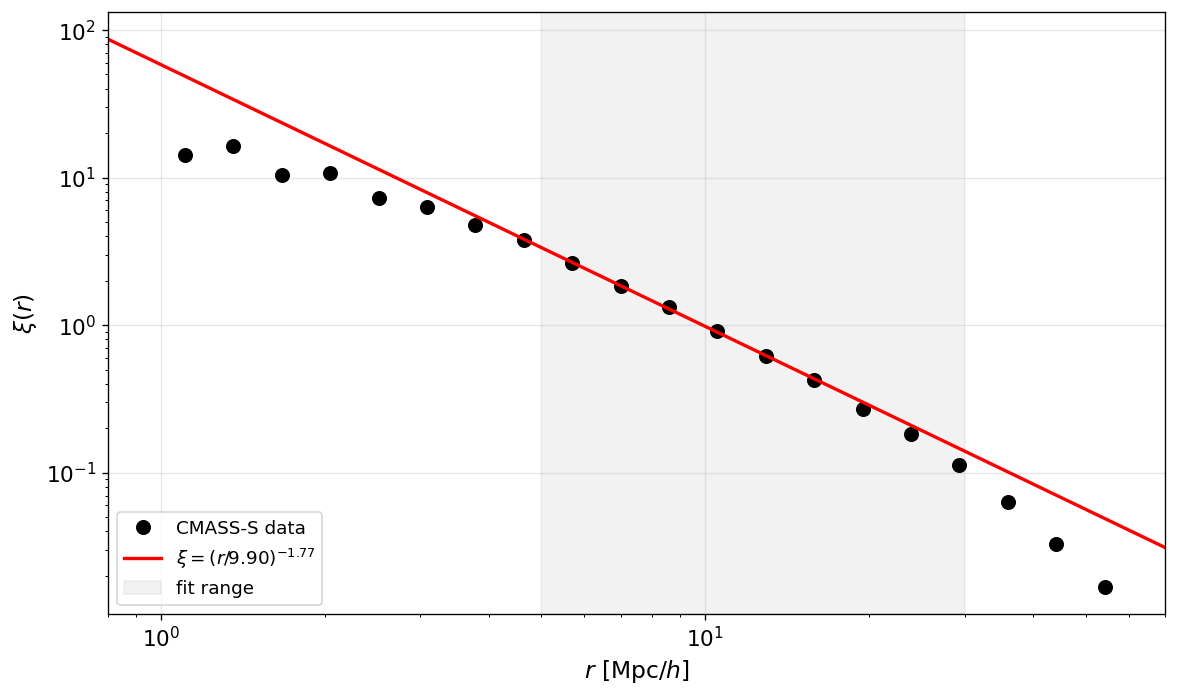

In [25]:
def power_law(r, r0, gamma):
    return (r / r0)**(-gamma)

# fit only on power-law regime
mask = (r_small > 5.) & (r_small < 30.0) & (xi_LS > 0)
popt, pcov = curve_fit(power_law, r_small[mask], xi_LS[mask], p0=[5.0, 1.8])
r0_fit, gamma_fit = popt
r0_err, gamma_err = np.sqrt(np.diag(pcov))
print(f'r0    = {r0_fit:.2f} +/- {r0_err:.2f}  Mpc/h')
print(f'gamma = {gamma_fit:.2f} +/- {gamma_err:.2f}')

rr = np.logspace(np.log10(0.8), np.log10(70), 100)
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(r_small, xi_LS, 'ko', ms=8, label='CMASS-S data')
ax.loglog(rr, power_law(rr, r0_fit, gamma_fit), 'r-', lw=2,
          label=f'$\\xi = (r/{r0_fit:.2f})^{{-{gamma_fit:.2f}}}$')
ax.axvspan(5., 30, color='gray', alpha=0.1, label='fit range')
ax.set_xlabel(r'$r$ [Mpc/$h$]'); ax.set_ylabel(r'$\xi(r)$')
ax.set_xlim(0.8, 70)
ax.legend(); plt.tight_layout(); plt.show()

### 2.2 --- Compare with CAMB linear theory + linear bias

From perturbation theory:
$$\xi_g(r) = b^2\,\frac{1}{2\pi^2}\int_0^\infty k^2 P_m(k)\,j_0(kr)\,dk\quad\text{with}\quad j_0(x)=\frac{\sin x}{x}$$

We use **CAMB** to obtain the (mildly nonlinear) matter power spectrum at the effective redshift, then numerically integrate.

In [42]:
import camb

pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=Ob0*h**2, omch2=(Om0-Ob0)*h**2)
pars.InitPower.set_params(ns=ns, As=As)
pars.set_matter_power(redshifts=[z_eff], kmax=100, k_per_logint=20, silent=True)
results = camb.get_results(pars)
PKint   = results.get_matter_power_interpolator(nonlinear=True, hubble_units=True, k_hunit=True)

kh   = np.exp(np.arange(-5.0, 4.5, 0.0001))   # k in h/Mpc
Pk_z = PKint.P(z_eff, kh)
print(f'CAMB P(k) computed at z_eff = {z_eff:.3f}')

CAMB P(k) computed at z_eff = 0.570


/tmp/ipykernel_14869/3346433787.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out[i] = bias**2 * np.trapz(kh**2 * Pk * np.sin(kh*r)/(kh*r), kh) / (2*np.pi**2)


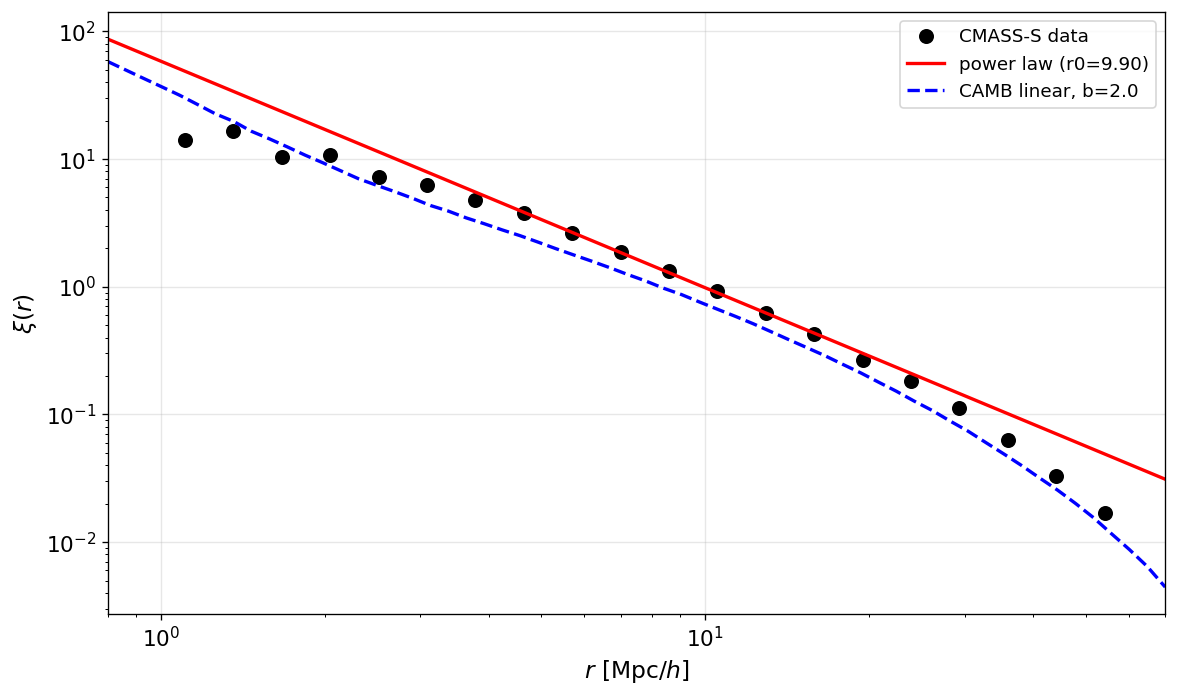

Try changing bias above and see how the CAMB curve shifts vertically.


In [53]:
def xi_from_pk(rvals, kh, Pk, bias=1.0):
    """Spherical Bessel transform: xi(r) = b^2 / (2 pi^2) int k^2 P j_0(kr) dk."""
    out = np.empty_like(rvals, dtype=float)
    for i, r in enumerate(rvals):
        out[i] = bias**2 * np.trapz(kh**2 * Pk * np.sin(kh*r)/(kh*r), kh) / (2*np.pi**2)
    return out

bias = 2.
rr   = np.logspace(np.log10(0.8), np.log10(70), 60)
xi_th = xi_from_pk(rr, kh, Pk_z, bias=bias)

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(r_small, xi_LS, 'ko', ms=8, label='CMASS-S data')
ax.loglog(rr, power_law(rr, r0_fit, gamma_fit), 'r-', lw=2,
          label=f'power law (r0={r0_fit:.2f})')
ax.loglog(rr, xi_th, 'b--', lw=2, label=f'CAMB linear, b={bias}')
ax.set_xlabel(r'$r$ [Mpc/$h$]'); ax.set_ylabel(r'$\xi(r)$')
ax.set_xlim(0.8, 70); ax.legend(); plt.tight_layout(); plt.show()

print('Try changing bias above and see how the CAMB curve shifts vertically.')

**Try it:** Vary `bias` from 1 to 3 in the cell above.  Find the value that brings the CAMB curve closest to the data on $r\sim 5$--$15\,h^{-1}\mathrm{Mpc}$.

## Part 3 --- BAO scale: fit the dilation parameter $\alpha$

On scales $r\sim 100\,h^{-1}\mathrm{Mpc}$ the correlation function shows a broad bump: the **baryon acoustic oscillation** feature, frozen into the matter distribution at the drag epoch ($z_d\approx 1060$).  Its location in comoving space is the sound horizon
$$r_s(z_d)=\int_0^{a_d}\frac{c_s\,da'}{a'^2 H(a')}\approx 147\;\mathrm{Mpc}$$
Because the physical $r_d$ is fixed by pre-recombination physics (and exquisitely calibrated by the CMB), the BAO feature acts as a **standard ruler**.  Measuring its apparent location at redshift $z$ gives us the dilation parameter
$$\alpha = \frac{D_V(z)\,r_{d,\rm fid}}{D_V^{\rm fid}(z)\,r_d},\qquad D_V(z) = \left[c\,z\,(1+z)^2\,D_A^2(z)\,H^{-1}(z)\right]^{1/3}.$$
$\alpha=1$ when our fiducial cosmology equals the truth.

We need errorbars to fit $\alpha$, so we run KSTAT with **jack-knife resampling** (5x5x3 = 75 sub-regions; we will report 125 from the deeper tessellation default).

In [32]:
# Carve up the survey volume into 5x5x5 = 125 jack-knife regions
!kstat/bin/jk.sh gal.txt ran.txt 5 3

working on  gal.txt ran.txt
Working with 3D data
chopping into 125 regions
number of lines: 216384
lines per file: 43277
performing x-axis split....
performing y-axis split....
performing z-axis split....
number of lines: 216384


In [33]:
# 12 linear bins from 45.5 to 122.5 Mpc/h with jack-knife covariance (~8 mins)
!kstat/bin/2pcf -gal gal.txt.jk -ran ran.txt.jk -rmin 45.5 -rmax 122.5 -nbins 12 -wgt .true. -err 'read' -nerr 125 > out_bao.txt 2>&1
!tail -15 out_bao.txt

 done with covariance
 writing resample files
   45.500000000000000        51.916666666666664        6.3604451942345401E-004
   51.916666666666664        58.333333333333336        7.9053550856798230E-004
   58.333333333333336        64.750000000000000        9.6262310485477484E-004
   64.750000000000000        71.166666666666671        1.1441508374062323E-003
   71.166666666666671        77.583333333333343        1.3402097479012361E-003
   77.583333333333343        84.000000000000000        1.5515462278839105E-003
   84.000000000000000        90.416666666666671        1.7765788498519614E-003
   90.416666666666671        96.833333333333343        2.0109808398321230E-003
   96.833333333333343        103.25000000000000        2.2556239661084649E-003
   103.25000000000000        109.66666666666667        2.5030998200131155E-003
   109.66666666666667        116.08333333333334        2.7547172393594726E-003
   116.08333333333334        122.50000000000000        3.0153642555827702E-003
 Exit.

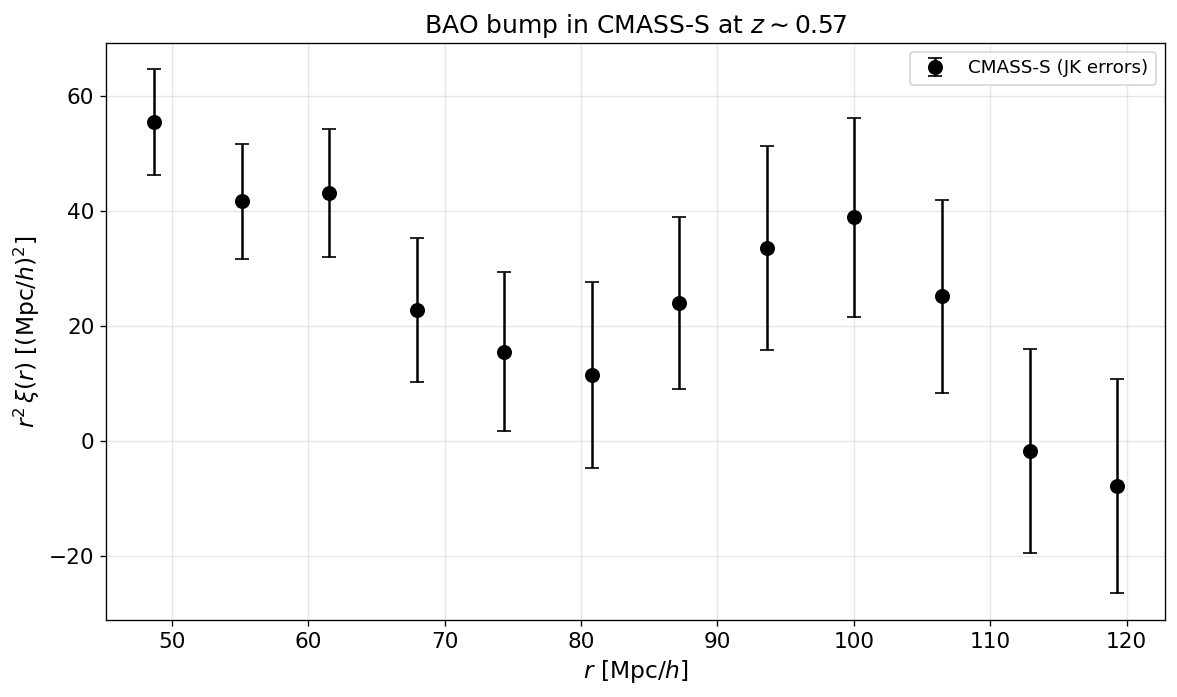

In [34]:
xb       = np.loadtxt('result.txt', skiprows=1)
r_bao    = 0.5 * (xb[:,0] + xb[:,1])
xi_bao   = xb[:,2]
xierr    = xb[:,3]

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(r_bao, r_bao**2 * xi_bao, yerr=r_bao**2 * xierr,
            fmt='ko', ms=8, capsize=4, label='CMASS-S (JK errors)')
ax.set_xlabel(r'$r$ [Mpc/$h$]'); ax.set_ylabel(r'$r^2\,\xi(r)$ [(Mpc/$h$)$^2$]')
ax.set_title(f'BAO bump in CMASS-S at $z\\sim {z_eff:.2f}$')
ax.legend(); plt.tight_layout(); plt.show()

### 3.1 --- Fit $\alpha$ with $\chi^2$ minimisation

Model: $\xi_{\rm model}(r) = b^2\,\xi_{\rm CAMB}(\alpha r) + A_{\rm shift}$,
with a small constant offset $A_{\rm shift}\sim 10^{-3}$ that absorbs broadband residuals (a stand-in for the more sophisticated polynomial nuisance terms used in actual BAO fits).

/tmp/ipykernel_14869/3346433787.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out[i] = bias**2 * np.trapz(kh**2 * Pk * np.sin(kh*r)/(kh*r), kh) / (2*np.pi**2)


alpha   = 1.0497
bias    = 2.398
chi^2   = 1.10 (dof = 10)


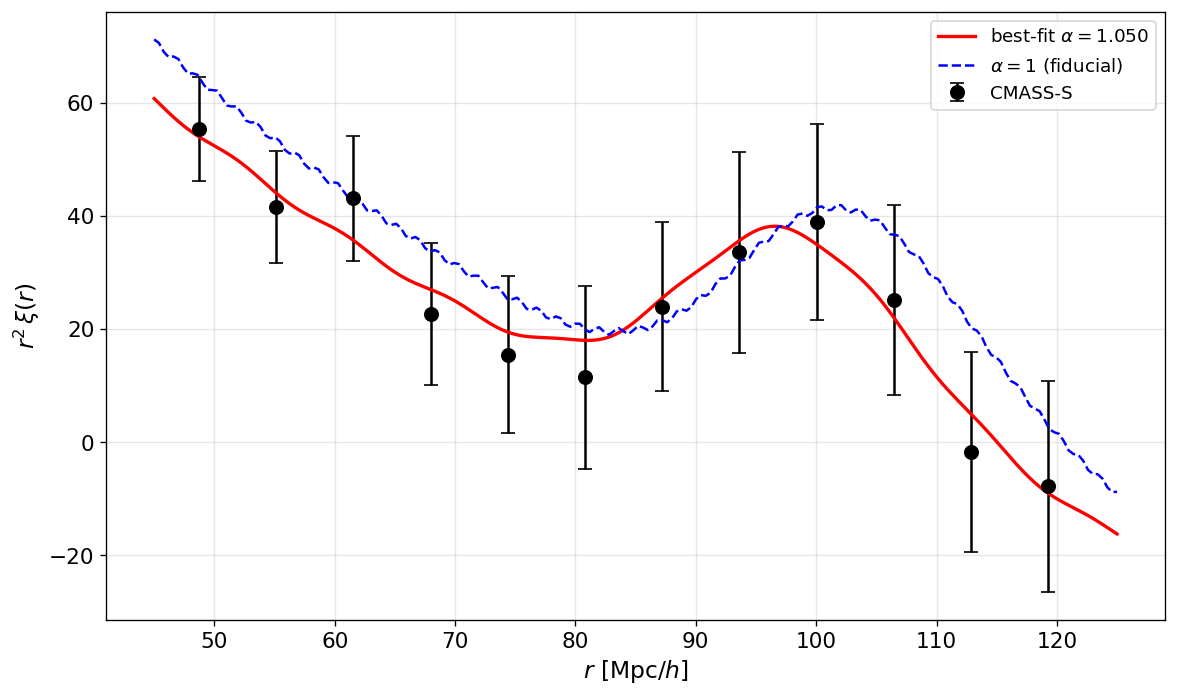

In [52]:
Ashift = 0.001

def bao_model(r_arr, alpha, bias):
    return bias**2 * xi_from_pk(alpha * r_arr, kh, Pk_z) #+ Ashift

def chi2_bao(params):
    alpha, bias = params
    return np.sum(((xi_bao - bao_model(r_bao, alpha, bias)) / xierr)**2)

fit = minimize(chi2_bao, x0=[1.0, 2.0], method='Nelder-Mead')
alpha_fit, bias_fit = fit.x
print(f'alpha   = {alpha_fit:.4f}')
print(f'bias    = {bias_fit:.3f}')
print(f'chi^2   = {fit.fun:.2f} (dof = {len(r_bao)-2})')

rgrid = np.linspace(45, 125, 200)
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(r_bao, r_bao**2 * xi_bao, yerr=r_bao**2 * xierr, fmt='ko', ms=8,
            capsize=4, label='CMASS-S')
ax.plot(rgrid, rgrid**2 * bao_model(rgrid, alpha_fit, bias_fit), 'r-', lw=2,
        label=f'best-fit $\\alpha={alpha_fit:.3f}$')
ax.plot(rgrid, rgrid**2 * bao_model(rgrid, 1.0, bias_fit), 'b--', lw=1.5,
        label=r'$\alpha=1$ (fiducial)')
ax.set_xlabel(r'$r$ [Mpc/$h$]'); ax.set_ylabel(r'$r^2\,\xi(r)$')
ax.legend(); plt.tight_layout(); plt.show()

In [61]:
ckms=299792.458 #km/s
h=0.67
Om=0.30
Ob=0.05
w0=-1.00

cosmo_h = FlatwCDM(H0=h*100.0, Om0=Om, w0=w0)

# Approximate sound horizon (Eisenstein-Hu fitting formula)
rd_fid = 153.5 * (Ob0*h*h/0.02273)**-0.134 * (Om0*h*h/0.1326)**-0.255
DA_fid = cosmo_h.angular_diameter_distance(z_eff).value      # Mpc/h
Hz_fid = cosmo_h.H(z_eff).value                              # h*km/s/Mpc, working in Mpc/h
DV_fid = (ckms * z_eff * (1+z_eff)**2 * DA_fid**2 / Hz_fid)**(1/3)

DV_meas = alpha_fit * DV_fid
print(f'Fiducial r_d (EH98)  = {rd_fid:.2f} Mpc')
print(f'Fiducial D_V({z_eff:.2f}) = {DV_fid:.1f} Mpc/h')
print(f'Measured D_V({z_eff:.2f}) = {DV_meas:.1f} Mpc/h  (alpha={alpha_fit:.3f})')
print(f'D_V/r_d              = {DV_meas/rd_fid:.2f}')

Fiducial r_d (EH98)  = 151.51 Mpc
Fiducial D_V(0.57) = 2088.3 Mpc/h
Measured D_V(0.57) = 2192.1 Mpc/h  (alpha=1.050)
D_V/r_d              = 14.47


### 3.2 --- BAO distance ladder
Compare our single point to the full SDSS BAO distance compilation.

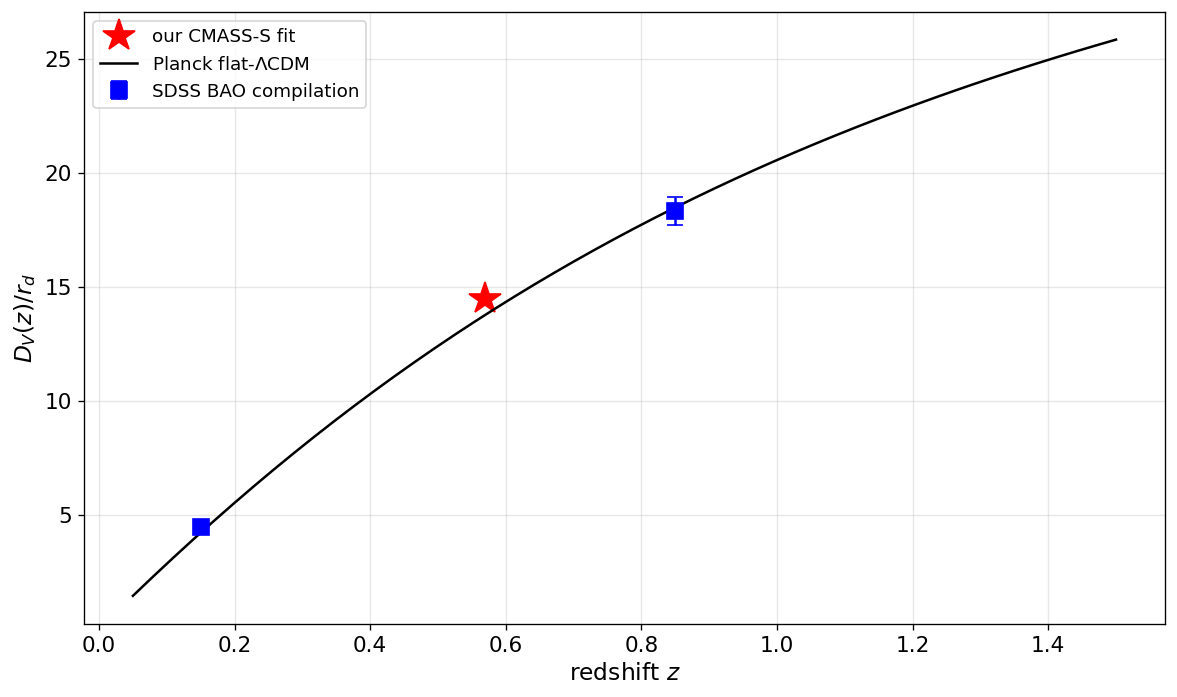

In [62]:
# SDSS final BAO compilation (BOSS + eBOSS): https://www.sdss.org/science/final-bao-and-rsd-measurements/
DV_data = np.array([4.47, 18.33])
DV_err  = np.array([0.17, 0.60])
DV_z    = np.array([0.15, 0.85])

# Theoretical prediction
zz   = np.linspace(0.05, 1.5, 50)
DV_z_th = (ckms * zz * (1+zz)**2 *
           cosmo_h.angular_diameter_distance(zz).value**2 /
           cosmo_h.H(zz).value)**(1/3)

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(DV_z, DV_data, yerr=DV_err, fmt='bs', ms=10, capsize=5, label='SDSS BAO compilation')
ax.plot(z_eff, DV_meas/rd_fid, 'r*', ms=20, label='our CMASS-S fit')
ax.plot(zz, DV_z_th/rd_fid, 'k-', lw=1.5, label='Planck flat-$\\Lambda$CDM')
ax.set_xlabel('redshift $z$'); ax.set_ylabel(r'$D_V(z)/r_d$')
ax.legend(); plt.tight_layout(); plt.show()

## Part 4 --- Anisotropic clustering and $f\sigma_8$

On scales smaller than the survey, redshift-space distortions break isotropy.  Switching to the pair separation decomposition
$\sigma$ (transverse) and $\pi$ (line-of-sight) we expect:
- **Kaiser squashing** along $\pi$ on large scales (coherent infall toward overdensities)
- **Fingers of God** elongation along $\pi$ on small scales (virial motions in clusters)

The Kaiser formula (linear infall, no FoG) reads
$$P_g^s(k,\mu) = \left(b_g + f\mu^2\right)^2 P_m(k),\qquad \mu = \hat{\bm k}\cdot\hat{\bm z}$$
with $f = d\ln D_+/d\ln a$ the linear growth rate.  We measure $\xi(\sigma,\pi)$ from the data and fit the Kaiser model to extract
$$f\sigma_8(z) = \beta\cdot b_g\sigma_8,\qquad \beta = f/b_g.$$

In [63]:
# Anisotropic 2D ξ(σ, π) on a 20x20 linear grid up to 60 Mpc/h (~2 mins)
!kstat/bin/2pcf -gal gal.txt -ran ran.txt -rmin 1.0 -rmax 60.0 -nbins 20 -wgt .true. -iso ANISO -decp SIGPI > out_aniso.txt 2>&1
!head -3 result.txt

Sig_min, Sig_max, Pi_min, Pi_max, DD, DR, RR, XI_natural, XI_Davis, XI_LS (most accurate)
 0.1000000E+01  0.3950000E+01  0.1000000E+01  0.3950000E+01  0.2909958E-05  0.4961313E-06  0.4985484E-06  0.4836862E+01  0.4865298E+01  0.4846559E+01
 0.1000000E+01  0.3950000E+01  0.3950000E+01  0.6900000E+01  0.1733261E-05  0.5038698E-06  0.5268237E-06  0.2290021E+01  0.2439899E+01  0.2377162E+01


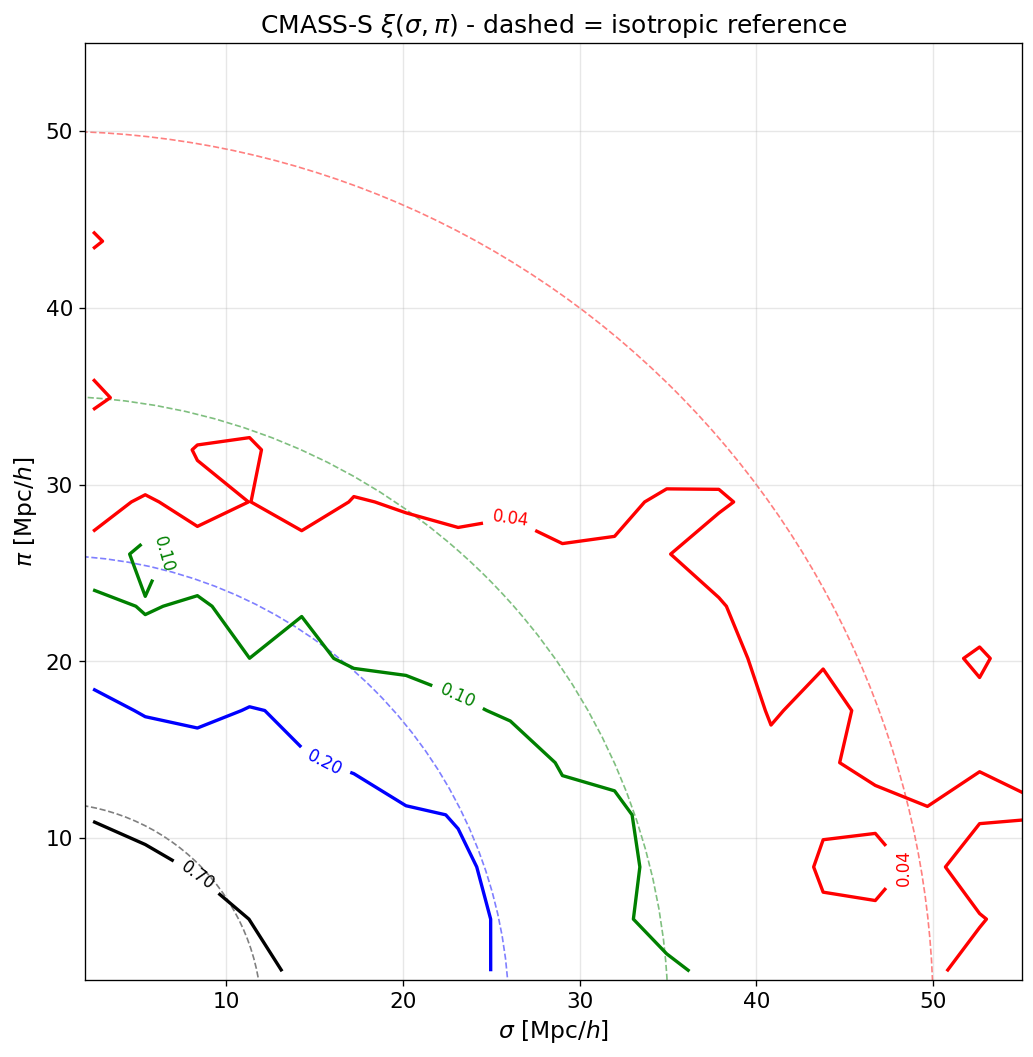

In [64]:
x   = np.loadtxt('result.txt', skiprows=1)
sig = np.mean(x[:, 0:2], axis=1).reshape((20, 20))
pi  = np.mean(x[:, 2:4], axis=1).reshape((20, 20))
xi2 = x[:, 9].reshape((20, 20))

fig, ax = plt.subplots(figsize=(9, 9))
cs = ax.contour(sig, pi, xi2, levels=[0.04, 0.1, 0.2, 0.7],
                colors=['r','g','b','k'], linewidths=2)
ax.clabel(cs, inline=True, fontsize=10, fmt='%.2f')
# Reference circles (what isotropic clustering would look like)
for R, col in [(12,'k'), (26,'b'), (35,'g'), (50,'r')]:
    ax.add_patch(plt.Circle((0,0), R, color=col, fill=False, linestyle='--', alpha=0.5))
ax.set_xlim(2, 55); ax.set_ylim(2, 55)
ax.set_xlabel(r'$\sigma$ [Mpc/$h$]'); ax.set_ylabel(r'$\pi$ [Mpc/$h$]')
ax.set_title(r'CMASS-S $\xi(\sigma,\pi)$ - dashed = isotropic reference')
ax.set_aspect('equal'); plt.tight_layout(); plt.show()

### 4.1 --- The Kaiser model (no FoG)

Compute the model $\xi(\sigma,\pi)$ from a Kaiser-distorted power spectrum:
$$\xi^{\rm Kaiser}(\sigma,\pi) = \frac{1}{2\pi^2}\int dk\, k^2 \,P_m(k)\,(b + f\mu^2)^2\,j_0(kr)$$
with $r=\sqrt{\sigma^2+\pi^2}$, $\mu=\pi/r$.  (This is a simplified treatment that fixes the angle-dependence inside the sin integral; for a fully correct Kaiser $\xi(\sigma,\pi)$ one should expand into multipoles, but the simple version is good enough for the qualitative match below.)

In [65]:
def xi_kaiser_2d(sigma, pi, kh, Pk_z, bias, f, sigma_v=None):
    """Simplified Kaiser xi(sigma,pi) with optional Gaussian FoG damping.
    sigma, pi : arrays of equal shape (Mpc/h)
    sigma_v   : if None, no FoG. Otherwise applies exp(-(k mu sigma_v)^2).
    Returns xi with the same shape.
    """
    s_arr = np.atleast_1d(sigma); p_arr = np.atleast_1d(pi)
    out = np.zeros_like(s_arr, dtype=float)
    flat_s = s_arr.ravel(); flat_p = p_arr.ravel()
    for n, (ss, pp) in enumerate(zip(flat_s, flat_p)):
        rr = np.sqrt(ss**2 + pp**2)
        if rr < 1e-3:
            continue
        mu  = pp / rr
        Pk_eff = (bias + f*mu**2)**2 * Pk_z
        if sigma_v is not None:
            Pk_eff = Pk_eff * np.exp(-(kh*mu*sigma_v)**2)
        out.flat[n] = np.trapz(kh**2 * Pk_eff * np.sin(kh*rr)/(kh*rr), kh) / (2*np.pi**2)
    return out.reshape(s_arr.shape)

# fiducial growth rate at z_eff in flat LCDM: f ~ Omega_m(z)^0.55
Om_z = Om0 * (1+z_eff)**3 / (Om0*(1+z_eff)**3 + (1-Om0))
f_lcdm = Om_z**0.55
print(f'fiducial f(z_eff)        = {f_lcdm:.3f}')
print(f'fiducial f*sigma_8       = {f_lcdm*sigma8:.3f}')

fiducial f(z_eff)        = 0.783
fiducial f*sigma_8       = 0.635


/tmp/ipykernel_14869/3310362959.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out.flat[n] = np.trapz(kh**2 * Pk_eff * np.sin(kh*rr)/(kh*rr), kh) / (2*np.pi**2)


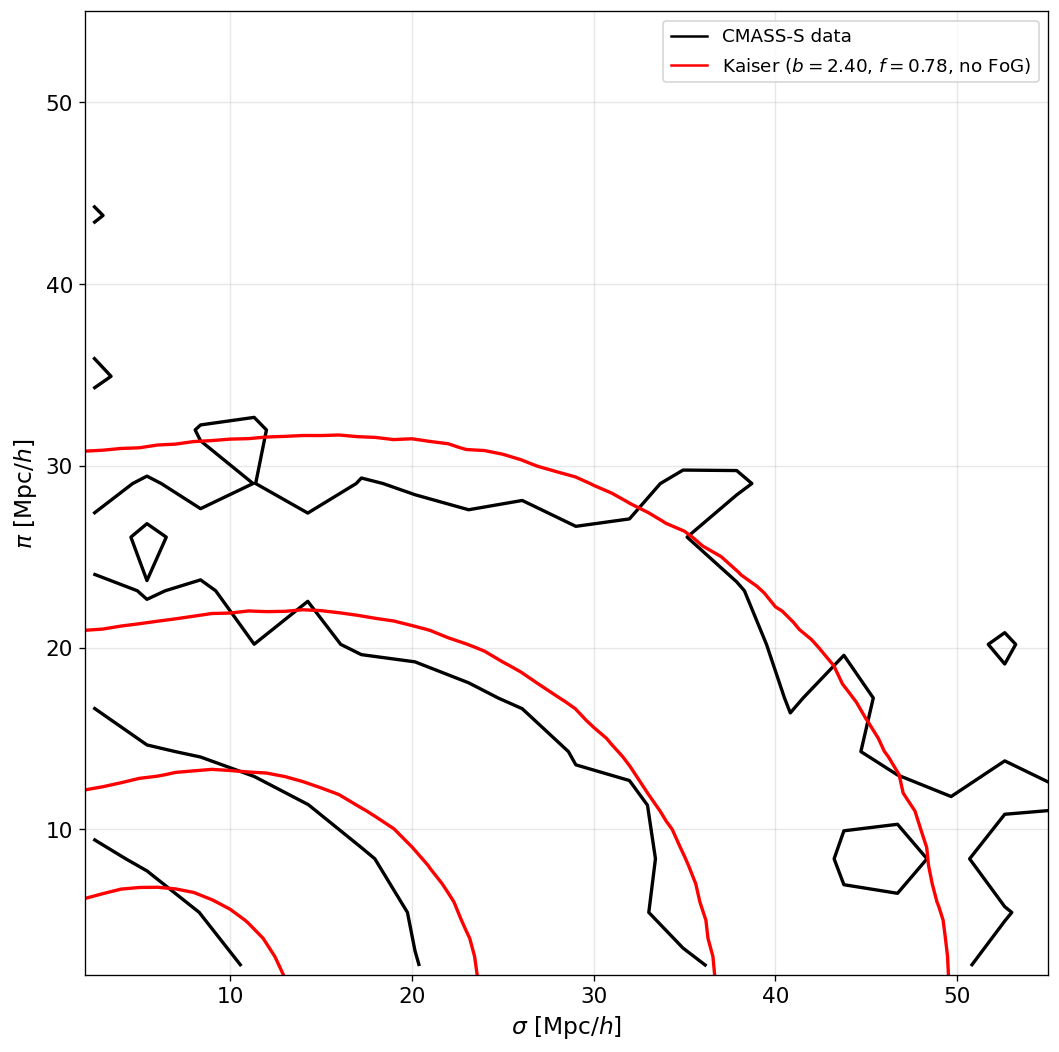

In [77]:
# Build a smooth (sigma, pi) grid for the Kaiser theory
sg, pg = np.meshgrid(np.linspace(1, 60, 60), np.linspace(1, 60, 60))

xi_no_fog = xi_kaiser_2d(sg, pg, kh, Pk_z, bias=1.5, f=1.5, sigma_v=None)

fig, ax = plt.subplots(figsize=(9, 9))
ax.contour(sig, pi, xi2,        levels=[0.04, 0.1, 0.3, 1], colors='k', linewidths=2)
ax.contour(sg,  pg, xi_no_fog.T,  levels=[0.04, 0.1, 0.3, 1], colors='r', linewidths=2)
ax.plot([], [], 'k-', label='CMASS-S data')
ax.plot([], [], 'r-', label=f'Kaiser ($b={bias_fit:.2f}$, $f={f_lcdm:.2f}$, no FoG)')
ax.set_xlim(2, 55); ax.set_ylim(2, 55)
ax.set_xlabel(r'$\sigma$ [Mpc/$h$]'); ax.set_ylabel(r'$\pi$ [Mpc/$h$]')
ax.set_aspect('equal'); ax.legend(); plt.tight_layout(); plt.show()

### 4.2 --- Fit $f\sigma_8$ from the 2D clustering

Holding $b\sigma_8$ fixed at the value that matches the *amplitude* of the data, scan $f$ and find the value that best matches the *anisotropy* of the contours.  The combination $f\sigma_8$ is what we report --- it is bias-independent.

In [73]:
# Restrict the fit to scales 6 < r < 30 Mpc/h to avoid FoG (small) and shot noise (very large)
rmask = ((sig > 6) & (sig < 30) & (pi > 6) & (pi < 30))

def chi2_fsig8(params):
    f, b = params
    model = xi_kaiser_2d(sig, pi, kh, Pk_z, bias=b, f=f, sigma_v=None)
    # crude Poisson-like weighting (no proper covariance for the practical)
    sig_xi = 0.05 * np.abs(xi2) + 0.005
    return np.sum(((xi2[rmask] - model.T[rmask]) / sig_xi[rmask])**2)

fit_rsd = minimize(chi2_fsig8, x0=[f_lcdm, bias_fit], method='Nelder-Mead')
f_fit, b_fit = fit_rsd.x
print(f'best-fit f      = {f_fit:.3f}')
print(f'best-fit b      = {b_fit:.3f}')
print(f'best-fit f*s8   = {f_fit*sigma8:.3f}     (LCDM expected: {f_lcdm*sigma8:.3f})')

/tmp/ipykernel_14869/3310362959.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out.flat[n] = np.trapz(kh**2 * Pk_eff * np.sin(kh*rr)/(kh*rr), kh) / (2*np.pi**2)


best-fit f      = 1.309
best-fit b      = 1.459
best-fit f*s8   = 1.062     (LCDM expected: 0.635)


### Exercise --- Add Fingers of God to the anisotropic model

On small scales virial motions in clusters disperse galaxies along the line of sight, producing finger-like elongation in $\xi(\sigma,\pi)$ that is **not** captured by the Kaiser formula.  A common phenomenological prescription is to multiply the redshift-space $P(k,\mu)$ by a Gaussian damping:
$$P_g^s(k,\mu) = (b_g + f\mu^2)^2\,P_m(k)\,e^{-(k\mu\sigma_v)^2}$$
where $\sigma_v$ is the 1D pairwise velocity dispersion (in $\mathrm{Mpc}/h$ when $k$ is in $h/\mathrm{Mpc}$).

**Tasks:**
1. The function `xi_kaiser_2d` already accepts a `sigma_v` keyword that activates the Gaussian FoG damping.  Use it with `sigma_v = 5.0` to compute a FoG-corrected model on the `(sg, pg)` grid.
2. Make a 3-curve contour plot overlaying:
   - the CMASS-S data (black)
   - the no-FoG Kaiser model (red, already computed as `xi_no_fog`)
   - your FoG-damped model (green)
3. Modify `chi2_fsig8` to fit *three* parameters $(f, b, \sigma_v)$ instead of two, and refit.  How much does the inferred $f\sigma_8$ change?
4. **Discussion:** why does the FoG damping suppress contours mainly at small $\sigma$ and large $\pi$?  Why does ignoring FoG bias the recovered $f\sigma_8$?

Use the cell below for your work.

In [ ]:
# ============================================================
# Exercise --- Fingers of God
# ============================================================

# Your code here


## Part 5 --- The Alcock$-$Paczy\'{n}ski distortion

Recall that we converted $(\alpha,\delta,z)\to(x,y,z)$ assuming a fiducial cosmology.  If the *true* cosmology differs, the inferred clustering will be geometrically warped.  Defining
$$\alpha_\perp = \frac{D_A^{\rm fid}}{D_A^{\rm true}},\qquad \alpha_\parallel = \frac{H^{\rm true}}{H^{\rm fid}},$$
the apparent and true clustering are related by
$$\xi^{\rm fid}(\sigma,\pi) = \xi^{\rm true}(\alpha_\perp\sigma,\;\alpha_\parallel\pi).$$
Importantly the AP effect probes pure geometry --- it depends on the distance$-$redshift relation, not the growth of structure.  In a real BAO+RSD analysis we fit ($\alpha_\perp,\alpha_\parallel,f\sigma_8,b\sigma_8$) jointly.

/tmp/ipykernel_14869/3310362959.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out.flat[n] = np.trapz(kh**2 * Pk_eff * np.sin(kh*rr)/(kh*rr), kh) / (2*np.pi**2)


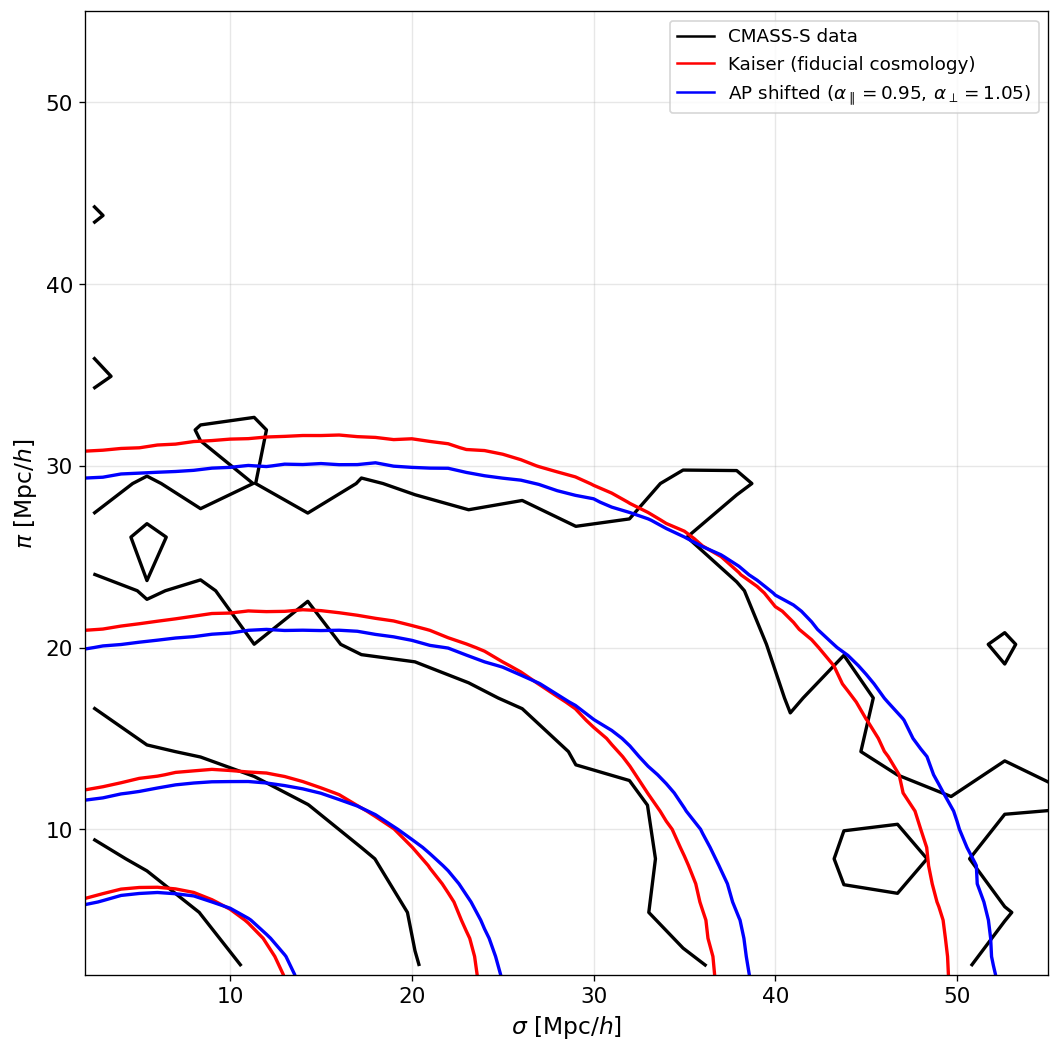

In [78]:
# Build the same Kaiser model but evaluated at AP-rescaled coordinates
alphapar = 0.95  # try varying these to see how the contours warp
alphaperp = 1.05

xi_ap = xi_kaiser_2d(alphaperp * sg, alphapar * pg, kh, Pk_z,
                       bias=1.5, f=1.5, sigma_v=None)

fig, ax = plt.subplots(figsize=(9, 9))
ax.contour(sig, pi, xi2,       levels=[0.04, 0.1, 0.3, 1], colors='k', linewidths=2)
ax.contour(sg,  pg, xi_no_fog.T, levels=[0.04, 0.1, 0.3, 1], colors='r', linewidths=2)
ax.contour(sg,  pg, xi_ap.T,     levels=[0.04, 0.1, 0.3, 1], colors='b', linewidths=2)
ax.plot([], [], 'k-', label='CMASS-S data')
ax.plot([], [], 'r-', label='Kaiser (fiducial cosmology)')
ax.plot([], [], 'b-', label=f'AP shifted ($\\alpha_\\parallel={alphapar},\\,\\alpha_\\perp={alphaperp}$)')
ax.set_xlim(2, 55); ax.set_ylim(2, 55)
ax.set_xlabel(r'$\sigma$ [Mpc/$h$]'); ax.set_ylabel(r'$\pi$ [Mpc/$h$]')
ax.set_aspect('equal'); ax.legend(); plt.tight_layout(); plt.show()

**Try it:** Vary $\alpha_\parallel$ and $\alpha_\perp$ in the cell above.  Note how the AP distortion warps contours geometrically (squashed/stretched circles) while the Kaiser effect produces a $\mu$-dependent amplitude modulation --- the two effects are not perfectly degenerate, which is why a joint BAO+RSD analysis breaks the geometry$-$dynamics degeneracy.

## Summary

In this practical you have:

- **Built a 3D galaxy + random catalogue** from real SDSS DR10 CMASS angular positions and redshifts, applying the proper systematics weighting
- **Measured $\xi(r)$ on small scales** and fit the canonical power-law form, recovering $r_0\sim 8\,h^{-1}\mathrm{Mpc}$ and $\gamma\sim 1.8$ for the LRG-dominated CMASS sample
- **Detected the BAO bump** at $r\sim 100\,h^{-1}\mathrm{Mpc}$ with jack-knife errors and fit the dilation parameter $\alpha$ to constrain $D_V/r_d$
- **Mapped the 2D clustering $\xi(\sigma,\pi)$**, identified the Kaiser squashing, and fit the bias-independent growth-rate observable $f\sigma_8$
- **Added Fingers of God** as a Gaussian damping and seen how it sharpens the small-scale anisotropy match (Exercise)
- **Visualised the Alcock$-$Paczy\'{n}ski distortion** by warping the model with $\alpha_\perp,\alpha_\parallel\neq 1$

Together, these are the same five steps a modern BAO+RSD analysis pipeline performs --- just at survey scale.